# Graph-Based ETA Prediction & Network Bottleneck Analysis

Predicts delivery ETA and flags network bottlenecks for a logistics company, using OSRM's own
time estimate as a baseline and improving on it with graph-derived features (hub centrality,
PageRank, historical delay patterns).

**What this notebook does, in order:**
1. **Data & Graph Construction** — clean the trip data, build a delivery corridor graph
   (train data only, so there's no leakage into the model).
2. **Hub Audit** — score every hub on network importance and how often it breaches SLA;
   flag the high-risk ones. This is the single definition of hub risk used everywhere below.
3. **ML Models** — Random Forest, CatBoost, and XGBoost, each with and without the graph
   features, benchmarked against the OSRM baseline. Also a simple ensemble of the three.
4. **Business Impact** — FTL vs. Carting trade-offs, estimated revenue at risk, and a
   strategy memo with concrete recommendations.
5. **Export** — save the models, features, and reports so a Streamlit app can serve them.

Run the cells top to bottom; each part builds on the one before it.


In [1]:
# Import everything we need: pandas/numpy for data wrangling,
# networkx for the delivery graph, matplotlib for charts,
# and the three ML libraries we'll compare (RandomForest, CatBoost, XGBoost).
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, export_text

from catboost import CatBoostRegressor
import xgboost as xgb

print("All imports successful.")


All imports successful.


In [2]:
# Load the raw delivery dataset and drop rows that are missing
# fields we absolutely need, or that have nonsensical (<=0) times.
BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "Dataset", "delivery_data.csv")

df = pd.read_csv(DATA_PATH)
print(f"Raw rows loaded: {len(df):,}")

essential_cols = [
    "trip_uuid", "source_center", "destination_center",
    "route_type", "actual_time", "osrm_time",
]
df = df.dropna(subset=essential_cols)
df = df[(df["actual_time"] > 0) & (df["osrm_time"] > 0)].copy()

# Keep string versions of the hub ids around — we'll use these as graph node ids.
df["source_center_raw"] = df["source_center"].astype(str)
df["destination_center_raw"] = df["destination_center"].astype(str)

print(f"Cleaned rows: {len(df):,}")
print(f"Columns ({df.shape[1]}):", df.columns.tolist())


Raw rows loaded: 144,867
Cleaned rows: 144,867
Columns (26): ['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type', 'trip_uuid', 'source_center', 'source_name', 'destination_center', 'destination_name', 'od_start_time', 'od_end_time', 'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor', 'source_center_raw', 'destination_center_raw']


In [3]:
# Parse the trip creation timestamp and bucket each trip into a time-of-day label.
df["trip_creation_time"] = pd.to_datetime(df["trip_creation_time"])
df["trip_hour"] = df["trip_creation_time"].dt.hour

def get_time_of_day(hour):
    # Simple rule of thumb for splitting the day into four shifts.
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["time_of_day"] = df["trip_hour"].apply(get_time_of_day)

print("Time-of-day distribution:")
print(df["time_of_day"].value_counts())


Time-of-day distribution:
time_of_day
Night        66339
Evening      34285
Morning      25077
Afternoon    19166
Name: count, dtype: int64


In [4]:
# Split by trip_uuid (not by row!) so that all legs of the same trip
# end up together on the same side of the split — otherwise we'd leak
# information about a trip from train into test.
trip_ids = df["trip_uuid"].drop_duplicates().to_numpy()
train_trips, test_trips = train_test_split(trip_ids, test_size=0.20, random_state=26)

df_train = df[df["trip_uuid"].isin(train_trips)].copy()
df_test = df[df["trip_uuid"].isin(test_trips)].copy()

train_idx = df_train.index
test_idx = df_test.index

print(f"Train trips: {len(train_trips):,}  |  Test trips: {len(test_trips):,}")
print(f"Train rows:  {len(df_train):,}     |  Test rows:  {len(df_test):,}")


Train trips: 11,853  |  Test trips: 2,964
Train rows:  115,939     |  Test rows:  28,928


In [5]:
# Collapse the training rows down to one row per (trip, corridor, time-of-day) leg,
# and work out how much slower the delivery actually was compared to OSRM's estimate.
trip_legs = df_train.groupby(
    ["trip_uuid", "source_center_raw", "destination_center_raw", "route_type", "time_of_day"]
).agg(
    actual_time=("actual_time", "max"),
    osrm_time=("osrm_time", "max"),
).reset_index()

trip_legs["delay_ratio"] = trip_legs["actual_time"] / trip_legs["osrm_time"]

print(f"Trip legs (train only): {len(trip_legs):,}")
print(trip_legs["delay_ratio"].describe().round(3))


Trip legs (train only): 21,225
count    21225.000
mean         2.549
std          2.608
min          0.388
25%          1.650
50%          2.000
75%          2.600
max         77.387
Name: delay_ratio, dtype: float64


In [6]:
# Roll the trip legs up one more level, to one row per corridor
# (source -> destination, route type, time of day), with a few delay stats.
corridors_df = trip_legs.groupby(
    ["source_center_raw", "destination_center_raw", "route_type", "time_of_day"]
).agg(
    median_delay_ratio=("delay_ratio", "median"),
    p90_delay_ratio=("delay_ratio", lambda x: x.quantile(0.9)),
    total_trips=("delay_ratio", "count"),
).reset_index()

print(f"Unique corridors (edges): {len(corridors_df):,}")
corridors_df.head()


Unique corridors (edges): 3,908


,source_center_raw,destination_center_raw,route_type,time_of_day,median_delay_ratio,p90_delay_ratio,total_trips
0,IND000000AAL,IND411033AAA,Carting,Afternoon,2.640000,4.505833,7
1,IND000000AAL,IND411033AAA,Carting,Evening,2.416667,3.391667,4
2,IND000000AAL,IND411033AAA,Carting,Morning,3.384615,3.384615,1
3,IND000000AAL,IND411033AAA,Carting,Night,2.018261,2.067652,2
4,IND000000AAQ,IND700028AAB,Carting,Night,6.071429,7.157143,2


In [7]:
# Turn the corridor table into an actual graph: every corridor becomes a
# directed edge, weighted by how delayed it typically is.
G = nx.MultiDiGraph()

for _, row in corridors_df.iterrows():
    G.add_edge(
        row["source_center_raw"],
        row["destination_center_raw"],
        weight=row["median_delay_ratio"],
        route_type=row["route_type"],
        time_of_day=row["time_of_day"],
        volume=row["total_trips"],
    )

print(f"Graph built — Nodes: {G.number_of_nodes():,}  Edges: {G.number_of_edges():,}")


Graph built — Nodes: 1,628  Edges: 3,908


In [8]:
# For every hub (node) in the graph, work out a handful of standard
# network-science metrics that describe how "important" or "busy" it is.
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())
betweenness = nx.betweenness_centrality(G, weight="weight", normalized=True)
pagerank = nx.pagerank(G, weight="weight")

# Clustering only makes sense on an undirected graph, so build one just for this.
G_undirected = nx.Graph(G)
clustering = nx.clustering(G_undirected)

# Build one row per hub instead of a wall of list comprehensions — easier to
# read and easier to add another metric to later.
hub_rows = []
for node in G.nodes():
    hub_rows.append({
        "hub_id": node,
        "in_degree": in_degree.get(node, 0),
        "out_degree": out_degree.get(node, 0),
        "betweenness_centrality": betweenness.get(node, 0),
        "clustering_coefficient": clustering.get(node, 0),
        "pagerank": pagerank.get(node, 0),
    })

hub_metrics = pd.DataFrame(hub_rows)
print(f"Hub metrics computed for {len(hub_metrics):,} hubs.")


Hub metrics computed for 1,628 hubs.


In [9]:
# Flag any corridor that's running noticeably slower than OSRM predicted
# (and has enough trips to trust the number), then roll that up per hub.
sla_threshold = 1.20
min_trips_to_trust = 5

is_breaching = corridors_df["median_delay_ratio"] > sla_threshold
has_enough_volume = corridors_df["total_trips"] >= min_trips_to_trust
breach_corridors = corridors_df[is_breaching & has_enough_volume].copy()

print(f"Total corridors:      {len(corridors_df):,}")
print(f"SLA breach corridors: {len(breach_corridors):,} ({100 * len(breach_corridors) / len(corridors_df):.2f}%)")

hub_breach_counts = (
    breach_corridors
    .groupby("source_center_raw")["total_trips"].sum()
    .reset_index()
    .rename(columns={"source_center_raw": "hub_id", "total_trips": "total_sla_breach_trips"})
)

# Join the breach counts onto the hub metrics; hubs with no breaches just get 0.
audit_df = pd.merge(hub_metrics, hub_breach_counts, on="hub_id", how="left").fillna(0)
audit_df = audit_df.sort_values("total_sla_breach_trips", ascending=False)

# A hub is "High Risk" if it's both structurally important (top quartile
# betweenness) AND responsible for a lot of breach volume (top quartile).
bc_thresh = audit_df["betweenness_centrality"].quantile(0.75)
vol_thresh = audit_df["total_sla_breach_trips"].quantile(0.75)

audit_df["risk_tier"] = "Low Risk"
is_high_risk = (audit_df["betweenness_centrality"] >= bc_thresh) & (audit_df["total_sla_breach_trips"] >= vol_thresh)
audit_df.loc[is_high_risk, "risk_tier"] = "High Risk"

print("\nRisk tier distribution:")
print(audit_df["risk_tier"].value_counts())
print("\nTop 10 bottleneck hubs:")
print(audit_df.head(10).round(4).to_string())


Total corridors:      3,908
SLA breach corridors: 1,641 (41.99%)

Risk tier distribution:
risk_tier
Low Risk     1459
High Risk     169
Name: count, dtype: int64

Top 10 bottleneck hubs:
            hub_id  in_degree  out_degree  betweenness_centrality  clustering_coefficient  pagerank  total_sla_breach_trips  risk_tier
25    IND000000ACB        101         108                  0.2338                  0.0372    0.0150                   728.0  High Risk
61    IND421302AAG         67          81                  0.0456                  0.0651    0.0078                   635.0  High Risk
12    IND562132AAA         78          86                  0.1232                  0.0519    0.0106                   495.0  High Risk
996   IND560099AAB         30          41                  0.0047                  0.1404    0.0035                   308.0  High Risk
1     IND411033AAA         38          43                  0.0491                  0.0616    0.0062                   289.0  High Risk
24 

Plots will be saved to: c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots


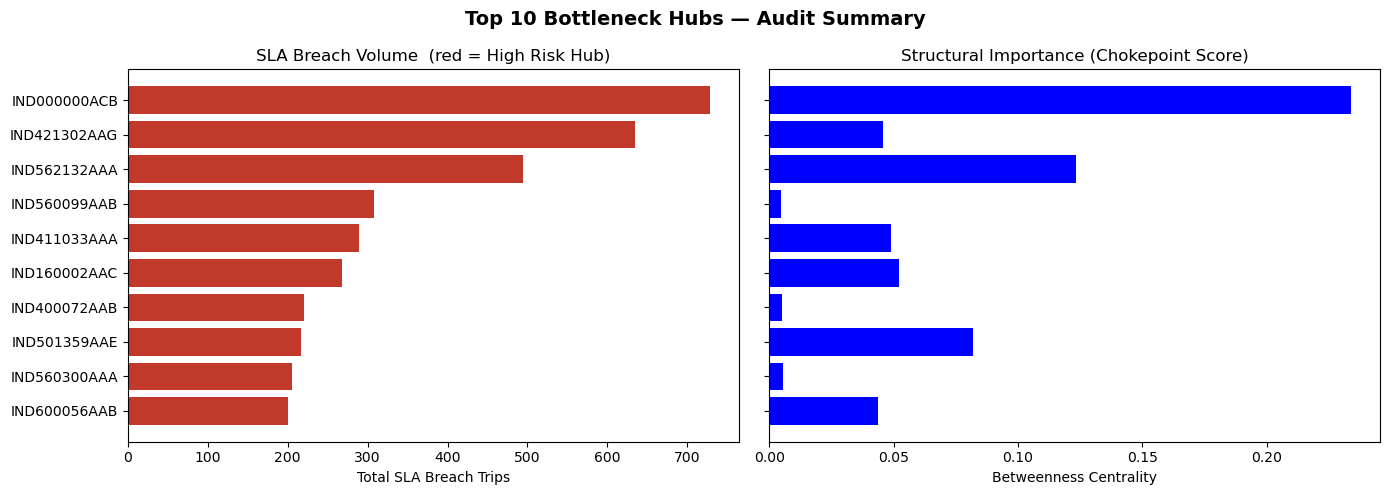

Saved: c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/bottleneck_hubs.png


In [10]:
# Plot the top 10 bottleneck hubs: one chart for breach volume, one for centrality.
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"Plots will be saved to: {PLOTS_DIR}")

top_hubs = audit_df.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Top 10 Bottleneck Hubs — Audit Summary", fontsize=14, fontweight="bold")

bar_colors = []
for tier in top_hubs["risk_tier"]:
    bar_colors.append("#C0392B" if tier == "High Risk" else "#7F8C8D")

axes[0].barh(top_hubs["hub_id"].astype(str), top_hubs["total_sla_breach_trips"], color=bar_colors)
axes[0].set_xlabel("Total SLA Breach Trips")
axes[0].set_title("SLA Breach Volume  (red = High Risk Hub)")
axes[0].invert_yaxis()

axes[1].barh(top_hubs["hub_id"].astype(str), top_hubs["betweenness_centrality"], color="blue")
axes[1].set_xlabel("Betweenness Centrality")
axes[1].set_title("Structural Importance (Chokepoint Score)")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bottleneck_hubs.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/bottleneck_hubs.png")


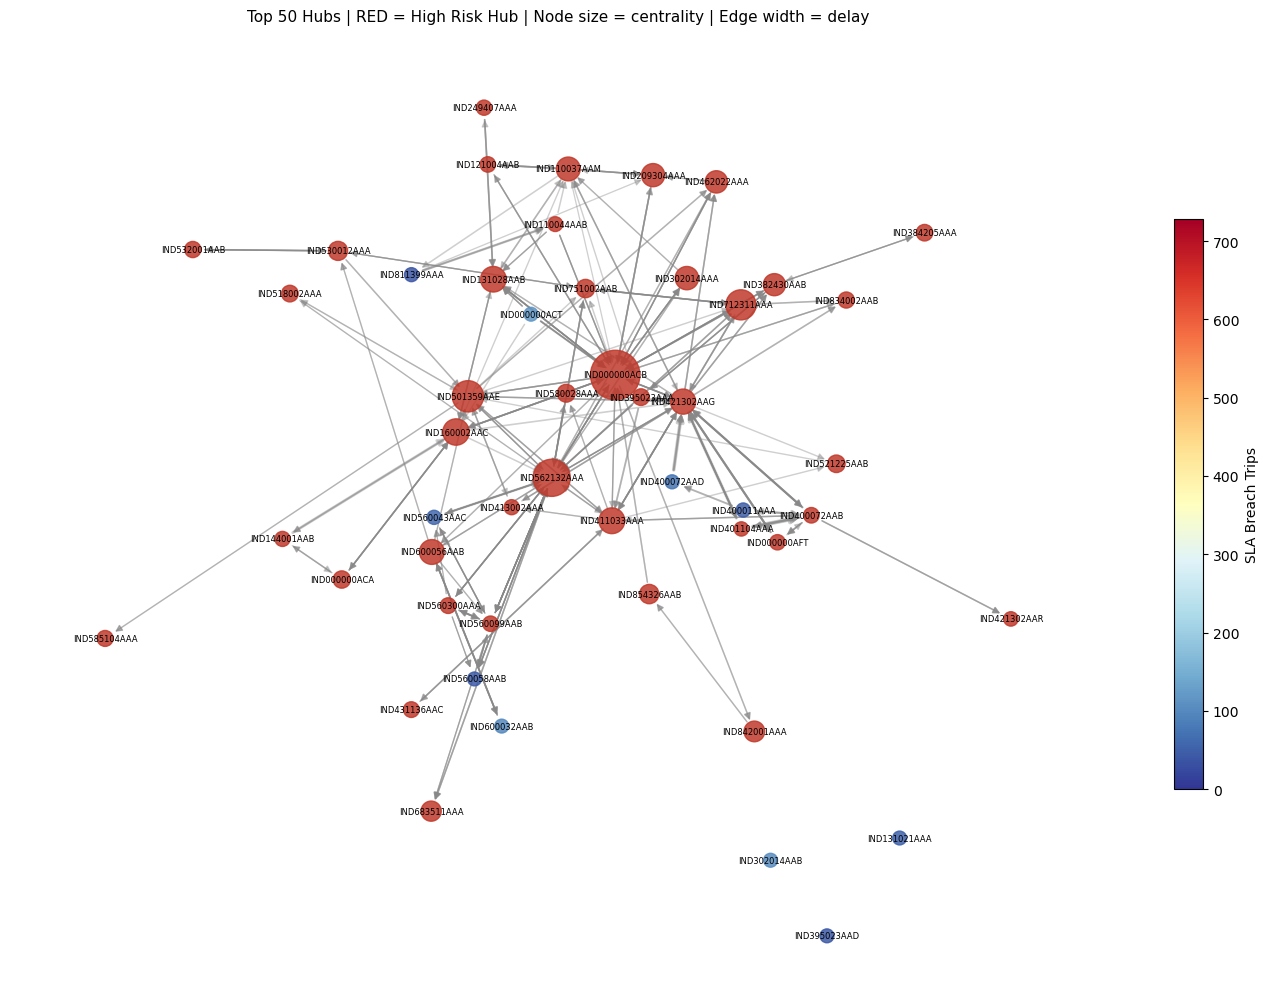

Saved: c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/network_graph.png


In [11]:
# Draw the top 50 hubs as a network graph.
# Node size shows how central the hub is, node color shows its risk/breach level,
# and edge thickness shows how delayed that corridor typically is.
top50_hubs = audit_df.head(50)["hub_id"].tolist()
subgraph = G.subgraph(top50_hubs)

risk_map = audit_df.set_index("hub_id")["risk_tier"].to_dict()
breach_map = audit_df.set_index("hub_id")["total_sla_breach_trips"].to_dict()
max_breach = max(breach_map.values())

node_sizes = []
node_colors = []
for node in subgraph.nodes():
    node_sizes.append(5000 * betweenness.get(node, 0.01) + 100)

    if risk_map.get(node) == "High Risk":
        node_colors.append("#C0392B")
    else:
        # Not flagged High Risk, so just shade it by how much breach volume it has.
        breach_share = breach_map.get(node, 0) / max_breach
        node_colors.append(plt.cm.RdYlBu_r(breach_share))

edge_weights = [d.get("weight", 1.0) for _, _, d in subgraph.edges(data=True)]
max_weight = max(edge_weights)
edge_widths = []
for w in edge_weights:
    edge_widths.append(0.5 + 2.5 * (w / max_weight))

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(subgraph, seed=26, k=0.8)

nx.draw_networkx_nodes(subgraph, pos, node_size=node_sizes, node_color=node_colors, alpha=0.85, ax=ax)
nx.draw_networkx_edges(subgraph, pos, width=edge_widths, edge_color="#888", alpha=0.4, arrows=True, arrowsize=10, ax=ax)
nx.draw_networkx_labels(subgraph, pos, font_size=6, ax=ax)

sm = plt.cm.ScalarMappable(cmap="RdYlBu_r", norm=mcolors.Normalize(vmin=0, vmax=max_breach))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="SLA Breach Trips", shrink=0.6)

ax.set_title("Top 50 Hubs | RED = High Risk Hub | Node size = centrality | Edge width = delay", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "network_graph.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/network_graph.png")


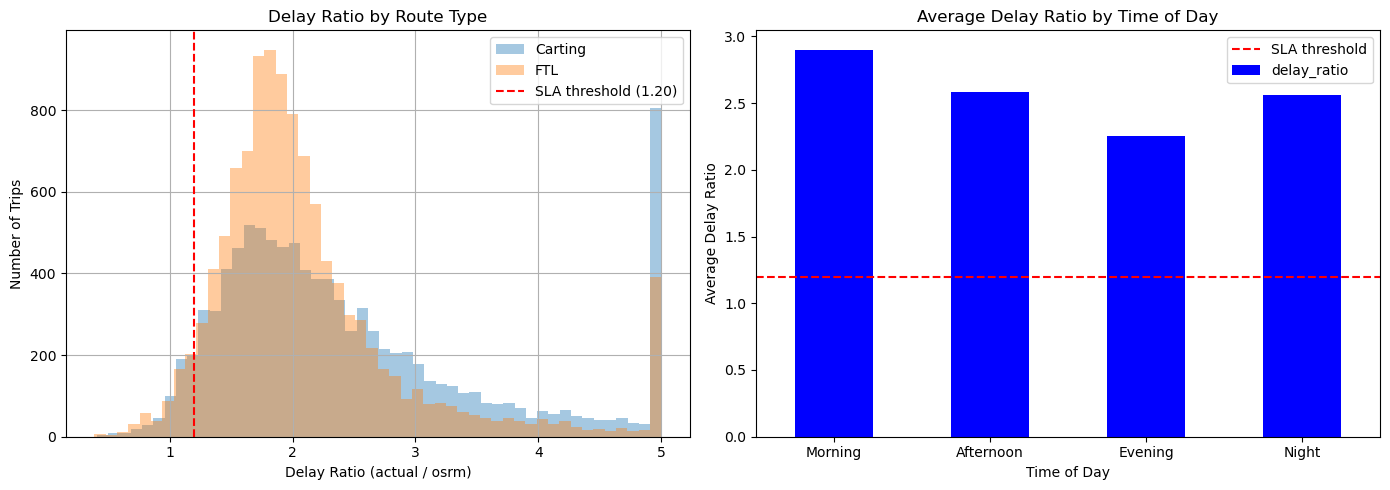

Saved: c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/delay_analysis.png


In [12]:
# Two views of the same "delay_ratio" story: distribution by route type,
# and the average by time of day.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for route_type, group in trip_legs.groupby("route_type"):
    group["delay_ratio"].clip(0, 5).hist(bins=50, alpha=0.4, label=route_type, ax=axes[0])
axes[0].axvline(1.2, color="red", linestyle="--", linewidth=1.5, label="SLA threshold (1.20)")
axes[0].set_xlabel("Delay Ratio (actual / osrm)")
axes[0].set_ylabel("Number of Trips")
axes[0].set_title("Delay Ratio by Route Type")
axes[0].legend()

time_of_day_order = ["Morning", "Afternoon", "Evening", "Night"]
avg_delay_by_time = trip_legs.groupby("time_of_day")["delay_ratio"].mean().reindex(time_of_day_order)
avg_delay_by_time.plot(kind="bar", color="blue", ax=axes[1], rot=0)
axes[1].axhline(1.2, color="red", linestyle="--", linewidth=1.5, label="SLA threshold")
axes[1].set_xlabel("Time of Day")
axes[1].set_ylabel("Average Delay Ratio")
axes[1].set_title("Average Delay Ratio by Time of Day")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "delay_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/delay_analysis.png")


In [13]:
# Pull a few more time-based features out of the timestamps, and
# turn route_type into a simple 0/1 flag for "is this a Full Truck Load".
df["od_start_time"] = pd.to_datetime(df["od_start_time"], errors="coerce")
df["od_hour"] = df["od_start_time"].dt.hour.fillna(0).astype(int)
df["od_weekday"] = df["od_start_time"].dt.weekday.fillna(0).astype(int)

df["day"] = df["trip_creation_time"].dt.day
df["month"] = df["trip_creation_time"].dt.month
df["weekday"] = df["trip_creation_time"].dt.weekday

df["route_type_FTL"] = (df["route_type"].astype(str).str.strip().str.upper() == "FTL").astype(int)

print(df["route_type"].value_counts(dropna=False))
print(df["route_type_FTL"].value_counts(dropna=False))
print("\nShape after feature creation:", df.shape)


route_type
FTL        99660
Carting    45207
Name: count, dtype: int64
route_type_FTL
1    99660
0    45207
Name: count, dtype: int64

Shape after feature creation: (144867, 34)


In [14]:
# Turn each hub into a 16-number "embedding" vector that summarizes its role
# in the network: how central it is, how much it delays outgoing/incoming
# shipments, and how much volume passes through it. We attach one of these
# for the hub as a *source* and another for it as a *destination* later,
# so each delivery row ends up with 32 graph-derived features in total.
EMBEDDING_DIM = 16

# Per-hub delay stats, split by whether the hub is the source or the destination.
outbound_delay_stats = corridors_df.groupby("source_center_raw")["median_delay_ratio"].agg(
    ["mean", "max", "std", "count"]).fillna(0)
inbound_delay_stats = corridors_df.groupby("destination_center_raw")["median_delay_ratio"].agg(
    ["mean", "max", "std", "count"]).fillna(0)

outbound_p90 = corridors_df.groupby("source_center_raw")["p90_delay_ratio"].mean().fillna(1.0)
inbound_p90 = corridors_df.groupby("destination_center_raw")["p90_delay_ratio"].mean().fillna(1.0)

# Normalize the graph metrics to a 0-1 range so no single feature dominates
# just because it happens to have a bigger raw scale.
max_in_degree = max(in_degree.values()) or 1
max_out_degree = max(out_degree.values()) or 1
max_betweenness = max(betweenness.values()) or 1
max_pagerank = max(pagerank.values()) or 1

embeddings = {}
for node in G.nodes():
    node_id = str(node)

    # --- structural features: what kind of hub is this in the network? ---
    betweenness_norm = betweenness.get(node, 0) / max_betweenness
    in_degree_norm = in_degree.get(node, 0) / max_in_degree
    out_degree_norm = out_degree.get(node, 0) / max_out_degree
    clustering_coef = clustering.get(node, 0)
    pagerank_norm = pagerank.get(node, 0) / max_pagerank
    # Ratio of outgoing to incoming connections — >1 means it ships out more than it receives.
    out_in_ratio = out_degree_norm / (in_degree_norm + 1e-6)

    # --- outbound delay features: how late are shipments LEAVING this hub? ---
    if node_id in outbound_delay_stats.index:
        out_delay_mean = outbound_delay_stats.loc[node_id, "mean"]
        out_delay_max = outbound_delay_stats.loc[node_id, "max"]
        out_delay_std = outbound_delay_stats.loc[node_id, "std"]
        out_corridor_count = outbound_delay_stats.loc[node_id, "count"]
    else:
        out_delay_mean, out_delay_max, out_delay_std, out_corridor_count = 1.0, 1.0, 0.0, 0.0
    out_delay_p90 = outbound_p90.get(node_id, 1.0)

    # --- inbound delay features: how late are shipments ARRIVING at this hub? ---
    if node_id in inbound_delay_stats.index:
        in_delay_mean = inbound_delay_stats.loc[node_id, "mean"]
        in_delay_max = inbound_delay_stats.loc[node_id, "max"]
        in_delay_std = inbound_delay_stats.loc[node_id, "std"]
        in_corridor_count = inbound_delay_stats.loc[node_id, "count"]
    else:
        in_delay_mean, in_delay_max, in_delay_std, in_corridor_count = 1.0, 1.0, 0.0, 0.0
    in_delay_p90 = inbound_p90.get(node_id, 1.0)

    embeddings[node_id] = np.array([
        betweenness_norm, in_degree_norm, out_degree_norm, clustering_coef, pagerank_norm, out_in_ratio,
        out_delay_mean, out_delay_max, out_delay_std, out_corridor_count / 100, out_delay_p90,
        in_delay_mean, in_delay_max, in_delay_std, in_corridor_count / 100, in_delay_p90,
    ], dtype=np.float32)

def get_emb(hub_raw_id):
    # Hubs we've never seen (e.g. only appear in the test set) just get all-zero embeddings.
    return embeddings.get(str(hub_raw_id), np.zeros(EMBEDDING_DIM, dtype=np.float32))

non_zero_count = sum(1 for v in embeddings.values() if np.any(v != 0))
print(f"Embeddings built: {len(embeddings):,} hubs x {EMBEDDING_DIM} dims")
print(f"Non-zero embeddings: {non_zero_count:,} / {len(embeddings):,}")


Embeddings built: 1,628 hubs x 16 dims
Non-zero embeddings: 1,628 / 1,628


In [15]:
# Look up each row's source-hub and destination-hub embedding and attach
# them as new columns (16 for source, 16 for destination = 32 columns).
src_cols = [f"src_emb_{i}" for i in range(EMBEDDING_DIM)]
dst_cols = [f"dst_emb_{i}" for i in range(EMBEDDING_DIM)]

src_embs = np.stack(df["source_center_raw"].apply(get_emb).values)
dst_embs = np.stack(df["destination_center_raw"].apply(get_emb).values)

for i, col in enumerate(src_cols):
    df[col] = src_embs[:, i]
for i, col in enumerate(dst_cols):
    df[col] = dst_embs[:, i]

# Also build a simple integer encoding of hub id, learned from the training
# hubs only — any hub only seen in test just gets -1 ("unknown").
src_categories = pd.Index(df_train["source_center_raw"].astype(str).unique())
dst_categories = pd.Index(df_train["destination_center_raw"].astype(str).unique())

src_mapping = {hub: i for i, hub in enumerate(src_categories)}
dst_mapping = {hub: i for i, hub in enumerate(dst_categories)}

df["source_center_enc"] = df["source_center_raw"].astype(str).map(src_mapping).fillna(-1).astype(int)
df["destination_center_enc"] = df["destination_center_raw"].astype(str).map(dst_mapping).fillna(-1).astype(int)

sample_emb = df[src_cols].values
print(f"Embedding check — non-zero src rows: {(sample_emb.sum(axis=1) != 0).sum():,} / {len(df):,}")
print("Any NaN in embeddings:", np.isnan(sample_emb).any())


Embedding check — non-zero src rows: 144,814 / 144,867
Any NaN in embeddings: False


In [16]:
# Encode time-of-day as an integer (fit on train only), then build two
# feature sets: a "baseline" one, and a "graph" one that also includes
# the 32 hub-embedding columns we just built.
le_time = LabelEncoder()
le_time.fit(df_train["time_of_day"].astype(str))

time_of_day_mapping = {label: i for i, label in enumerate(le_time.classes_)}
df["time_of_day_encoded"] = df["time_of_day"].astype(str).map(time_of_day_mapping).fillna(-1).astype(int)

candidate_cols = [
    "source_center_enc", "destination_center_enc",
    "is_cutoff", "cutoff_factor",
    "actual_distance_to_destination",
    "osrm_time", "osrm_distance",
    "segment_osrm_time", "segment_osrm_distance",
    "time_of_day_encoded", "day", "month", "weekday",
    "route_type_FTL", "od_hour", "od_weekday",
]
# Only keep columns that actually exist in this dataset (some are optional).
baseline_features = [c for c in candidate_cols if c in df.columns]
enhanced_features = baseline_features + src_cols + dst_cols

X_base = df[baseline_features].fillna(0)
X_graph = df[enhanced_features].fillna(0)
y = df["actual_time"].values

X_train, X_test = X_base.loc[train_idx], X_base.loc[test_idx]
X_train_g, X_test_g = X_graph.loc[train_idx], X_graph.loc[test_idx]
y_train, y_test = df.loc[train_idx, "actual_time"].values, df.loc[test_idx, "actual_time"].values
# The target is the same whether we're using baseline or graph features.
y_train_g, y_test_g = y_train, y_test

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Baseline features: {len(baseline_features)}  |  Graph features: {len(enhanced_features)}")


Train: 115,939  |  Test: 28,928
Baseline features: 16  |  Graph features: 48


In [17]:
# Shared metric used by every model below: what % of predictions land
# within `tol` (default 15%) of the true delivery time?
def accuracy_within_tolerance(y_true, y_pred, tol=0.15):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    absolute_pct_error = np.abs((y_true - y_pred) / np.maximum(y_true, 1e-6))
    return (absolute_pct_error <= tol).mean() * 100


## 1. Random Forest Model


In [18]:
# Random Forest on the baseline features (no graph info).
rf_baseline = RandomForestRegressor(n_estimators=250, max_depth=8, random_state=26, n_jobs=-1, oob_score=True)
rf_baseline.fit(X_train, y_train)
y_pred_rf = rf_baseline.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)
rf_acc15 = accuracy_within_tolerance(y_test, y_pred_rf)

# Same model, but now with the 32 graph-embedding columns included too —
# this is what we actually want to compare against the baseline.
rf_graph = RandomForestRegressor(n_estimators=250, max_depth=8, random_state=26, n_jobs=-1, oob_score=True)
rf_graph.fit(X_train_g, y_train_g)
y_pred_rf_graph = rf_graph.predict(X_test_g)

rf_graph_mae = mean_absolute_error(y_test_g, y_pred_rf_graph)
rf_graph_r2 = r2_score(y_test_g, y_pred_rf_graph)
rf_graph_acc15 = accuracy_within_tolerance(y_test_g, y_pred_rf_graph)

print("RF BASELINE")
print(f"  OOB R2:       {rf_baseline.oob_score_:.4f}  (free validation signal, no extra split needed)")
print(f"  MAE:          {rf_mae:.2f} min")
print(f"  r2:           {rf_r2:.4f}")
print(f"  Acc@15%:      {rf_acc15:.1f}%")

print("RF + GRAPH EMBEDDINGS")
print(f"  OOB R2:       {rf_graph.oob_score_:.4f}  (compare to test R2 below to check overfitting)")
print(f"  MAE:          {rf_graph_mae:.2f} min")
print(f"  r2:           {rf_graph_r2:.4f}")
print(f"  Acc@15%:      {rf_graph_acc15:.1f}%")

print(f"Improvement over RF Baseline: MAE {rf_mae - rf_graph_mae:+.2f} min")


RF BASELINE
  OOB R2:       0.9729  (free validation signal, no extra split needed)
  MAE:          47.40 min
  r2:           0.9772
  Acc@15%:      47.1%
RF + GRAPH EMBEDDINGS
  OOB R2:       0.9769  (compare to test R2 below to check overfitting)
  MAE:          44.43 min
  r2:           0.9805
  Acc@15%:      48.8%
Improvement over RF Baseline: MAE +2.97 min


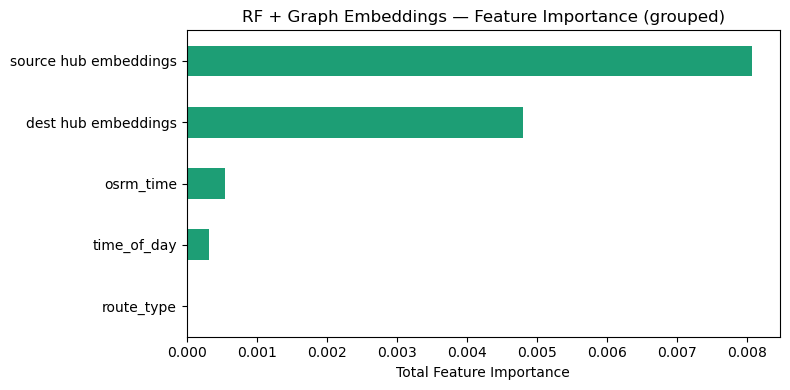

Saved: c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/rf_graph_importance.png


In [19]:
# Group the individual feature importances into a few human-readable
# buckets so the chart isn't 40+ tiny bars.
rf_importance = pd.Series(rf_graph.feature_importances_, index=enhanced_features)
grouped_rf_importance = {
    "osrm_time": rf_importance.get("osrm_time", 0),
    "time_of_day": rf_importance.get("time_of_day_encoded", 0),
    "route_type": rf_importance.get("route_type_FTL", 0),
    "source hub embeddings": rf_importance[src_cols].sum(),
    "dest hub embeddings": rf_importance[dst_cols].sum(),
}

fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(grouped_rf_importance).sort_values().plot(kind="barh", color="#1D9E75", ax=ax)
ax.set_xlabel("Total Feature Importance")
ax.set_title("RF + Graph Embeddings — Feature Importance (grouped)")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "rf_graph_importance.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/rf_graph_importance.png")


## 2. CatBoost


In [20]:
# Carve a small validation slice out of the training rows (not the held-out
# test set) so CatBoost and XGBoost can early-stop instead of always running
# the full 250 iterations regardless of whether that's the right amount.
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=26)
X_tr_g, X_val_g, y_tr_g, y_val_g = train_test_split(X_train_g, y_train_g, test_size=0.15, random_state=26)

# CatBoost on the baseline features.
cb_baseline = CatBoostRegressor(
    iterations=250,
    depth=8,
    learning_rate=0.05,
    random_seed=26,
    thread_count=-1,
    early_stopping_rounds=30,
    verbose=False,
)
cb_baseline.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)
y_pred_cb = cb_baseline.predict(X_test)

cb_mae = mean_absolute_error(y_test, y_pred_cb)
cb_r2 = r2_score(y_test, y_pred_cb)
cb_acc15 = accuracy_within_tolerance(y_test, y_pred_cb)

# Same model, with graph embeddings added.
cb_graph = CatBoostRegressor(
    iterations=250,
    depth=8,
    learning_rate=0.05,
    random_seed=26,
    thread_count=-1,
    early_stopping_rounds=30,
    verbose=False,
)
cb_graph.fit(X_tr_g, y_tr_g, eval_set=(X_val_g, y_val_g), use_best_model=True)
y_pred_cb_graph = cb_graph.predict(X_test_g)

cb_graph_mae = mean_absolute_error(y_test_g, y_pred_cb_graph)
cb_graph_r2 = r2_score(y_test_g, y_pred_cb_graph)
cb_graph_acc15 = accuracy_within_tolerance(y_test_g, y_pred_cb_graph)

print("CB BASELINE")
print(f"  Best iter:    {cb_baseline.get_best_iteration()} / 250 (early stopping)")
print(f"  MAE:          {cb_mae:.2f} min")
print(f"  r2:           {cb_r2:.4f}")
print(f"  Acc@15%:      {cb_acc15:.1f}%")

print("CB + GRAPH EMBEDDINGS")
print(f"  Best iter:    {cb_graph.get_best_iteration()} / 250 (early stopping)")
print(f"  MAE:          {cb_graph_mae:.2f} min")
print(f"  r2:           {cb_graph_r2:.4f}")
print(f"  Acc@15%:      {cb_graph_acc15:.1f}%")

print(f"Improvement over CB Baseline: MAE {cb_mae - cb_graph_mae:+.2f} min")


CB BASELINE
  Best iter:    249 / 250 (early stopping)
  MAE:          45.15 min
  r2:           0.9797
  Acc@15%:      48.8%
CB + GRAPH EMBEDDINGS
  Best iter:    249 / 250 (early stopping)
  MAE:          40.31 min
  r2:           0.9837
  Acc@15%:      55.3%
Improvement over CB Baseline: MAE +4.84 min


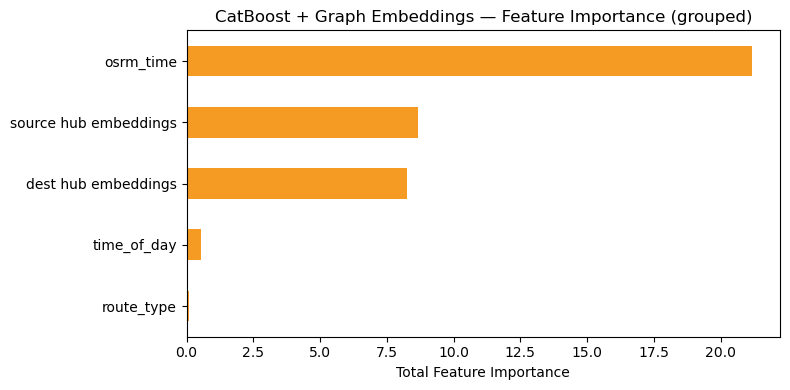

Saved: c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/cb_graph_importance.png


In [21]:
# Same grouped-importance idea as the RF chart, this time for CatBoost.
cb_importance = pd.Series(cb_graph.get_feature_importance(), index=enhanced_features)
grouped_cb_importance = {
    "osrm_time": cb_importance.get("osrm_time", 0),
    "time_of_day": cb_importance.get("time_of_day_encoded", 0),
    "route_type": cb_importance.get("route_type_FTL", 0),
    "source hub embeddings": cb_importance[src_cols].sum(),
    "dest hub embeddings": cb_importance[dst_cols].sum(),
}

fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(grouped_cb_importance).sort_values().plot(kind="barh", color="#F59B23", ax=ax)
ax.set_xlabel("Total Feature Importance")
ax.set_title("CatBoost + Graph Embeddings — Feature Importance (grouped)")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "cb_graph_importance.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/cb_graph_importance.png")


## 3. XGBoost


XGBOOST BASELINE
  Best iter:    249 / 250 (early stopping)
  MAE:          41.65 min
  r2:           0.9809
  Acc@15%:      54.4%
XGBOOST + GRAPH EMBEDDINGS
  Best iter:    248 / 250 (early stopping)
  MAE:          37.89 min
  r2:           0.9831
  Acc@15%:      61.3%
Improvement over XGB Baseline: MAE +3.76 min


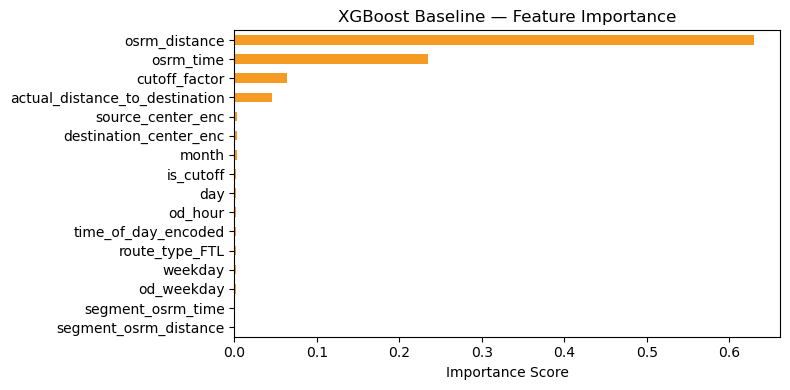

Saved: c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/xgb_baseline_importance.png


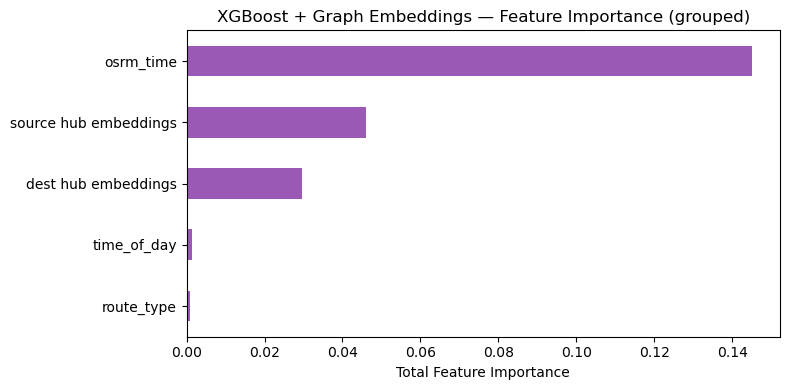

Saved: c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/xgb_graph_importance.png


In [22]:
# XGBoost on the baseline features.
xgb_baseline = xgb.XGBRegressor(
    n_estimators=250, learning_rate=0.05, max_depth=8,
    subsample=0.8, colsample_bytree=0.8,
    random_state=26, n_jobs=-1, verbosity=0,
    early_stopping_rounds=30,
)
# Reuses the X_tr/X_val validation carve-out created in the CatBoost cell above.
xgb_baseline.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
y_pred_xgb = xgb_baseline.predict(X_test)

xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_acc15 = accuracy_within_tolerance(y_test, y_pred_xgb)

# Same model, with graph embeddings added.
xgb_graph = xgb.XGBRegressor(
    n_estimators=250, learning_rate=0.05, max_depth=8,
    subsample=0.8, colsample_bytree=0.8,
    random_state=26, n_jobs=-1, verbosity=0,
    early_stopping_rounds=30,
)
xgb_graph.fit(X_tr_g, y_tr_g, eval_set=[(X_val_g, y_val_g)], verbose=False)
y_pred_xgb_graph = xgb_graph.predict(X_test_g)

xgb_graph_mae = mean_absolute_error(y_test_g, y_pred_xgb_graph)
xgb_graph_r2 = r2_score(y_test_g, y_pred_xgb_graph)
xgb_graph_acc15 = accuracy_within_tolerance(y_test_g, y_pred_xgb_graph)

print("XGBOOST BASELINE")
print(f"  Best iter:    {xgb_baseline.best_iteration} / 250 (early stopping)")
print(f"  MAE:          {xgb_mae:.2f} min")
print(f"  r2:           {xgb_r2:.4f}")
print(f"  Acc@15%:      {xgb_acc15:.1f}%")

print("XGBOOST + GRAPH EMBEDDINGS")
print(f"  Best iter:    {xgb_graph.best_iteration} / 250 (early stopping)")
print(f"  MAE:          {xgb_graph_mae:.2f} min")
print(f"  r2:           {xgb_graph_r2:.4f}")
print(f"  Acc@15%:      {xgb_graph_acc15:.1f}%")

print(f"Improvement over XGB Baseline: MAE {xgb_mae - xgb_graph_mae:+.2f} min")

# Baseline feature importance chart.
fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(xgb_baseline.feature_importances_, index=baseline_features).sort_values().plot(
    kind="barh", color="#F59B23", ax=ax)
ax.set_title("XGBoost Baseline — Feature Importance")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "xgb_baseline_importance.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/xgb_baseline_importance.png")

# Grouped feature importance chart for the graph-enhanced model.
xgb_importance = pd.Series(xgb_graph.feature_importances_, index=enhanced_features)
grouped_xgb_importance = {
    "osrm_time": xgb_importance.get("osrm_time", 0),
    "time_of_day": xgb_importance.get("time_of_day_encoded", 0),
    "route_type": xgb_importance.get("route_type_FTL", 0),
    "source hub embeddings": xgb_importance[src_cols].sum(),
    "dest hub embeddings": xgb_importance[dst_cols].sum(),
}

fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(grouped_xgb_importance).sort_values().plot(kind="barh", color="#9B59B6", ax=ax)
ax.set_xlabel("Total Feature Importance")
ax.set_title("XGBoost + Graph Embeddings — Feature Importance (grouped)")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "xgb_graph_importance.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/xgb_graph_importance.png")


In [23]:
# How good is OSRM's own estimate, with no ML at all? This is the bar
# every model above needs to clear.
osrm_mae = mean_absolute_error(y_test, X_test["osrm_time"])
osrm_r2 = r2_score(y_test, X_test["osrm_time"])
osrm_acc15 = accuracy_within_tolerance(y_test, X_test["osrm_time"])

print("OSRM Scores")
print(f"  MAE:          {osrm_mae:.2f} min")
print(f"  r2:           {osrm_r2:.4f}")
print(f"  Acc@15%:      {osrm_acc15:.1f}%")


OSRM Scores
  MAE:          201.90 min
  r2:           0.6386
  Acc@15%:      4.3%


7-MODEL COMPARISON SUMMARY
Metric             OSRM         RF         CB       XGBoost   RF+Graph   CB_Graph   XGB+Graph
-----------------------------------------------------------------------------------------------
MAE (min)        201.90      47.40      45.15         41.65      44.43      40.31       37.89
Acc@15% (%)        4.26      47.11      48.85         54.45      48.76      55.29       61.30


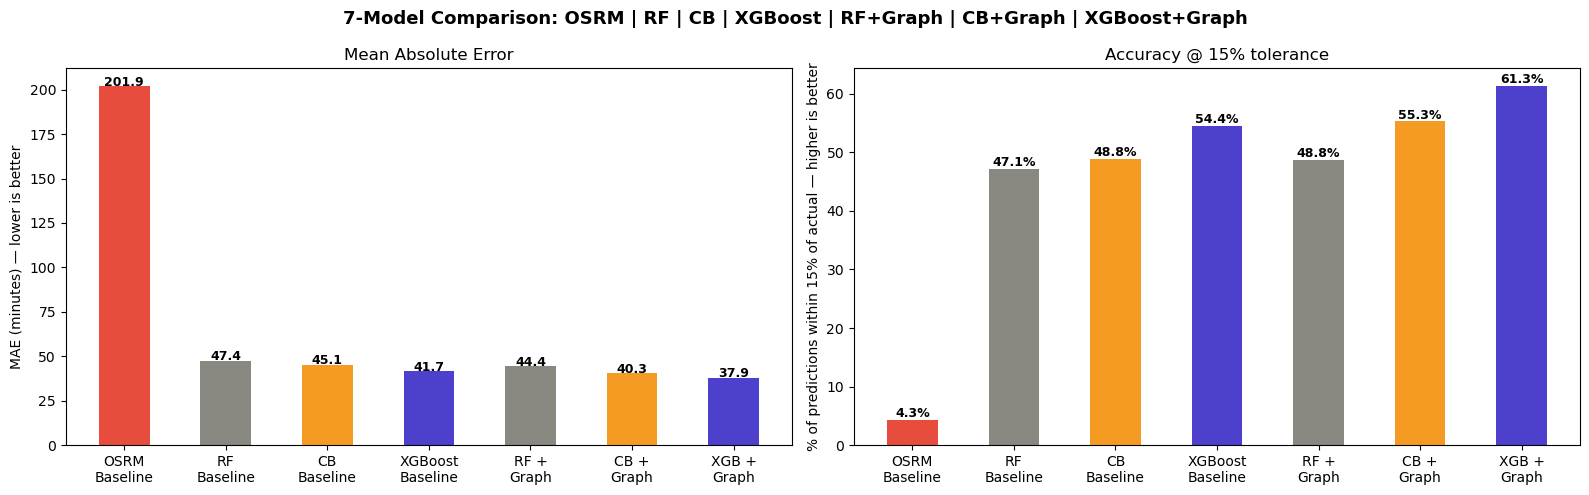

Saved: c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/model_comparison.png

Best graph-enhanced model by MAE: XGB+Graph (37.89 min)


In [24]:
# Line them all up: OSRM baseline vs the 3 ML models vs the same 3 ML
# models with graph embeddings added.
def format_metric(value):
    return f"{value:.2f}" if value is not None else "N/A"

print("7-MODEL COMPARISON SUMMARY")
print("=" * 95)
print(f"{'Metric':<12} {'OSRM':>10} {'RF':>10} {'CB':>10} {'XGBoost':>13} {'RF+Graph':>10} {'CB_Graph':>10} {'XGB+Graph':>11}")
print("-" * 95)
print(f"{'MAE (min)':<14} {format_metric(osrm_mae):>8} {format_metric(rf_mae):>10} {format_metric(cb_mae):>10} "
      f"{format_metric(xgb_mae):>13} {format_metric(rf_graph_mae):>10} {format_metric(cb_graph_mae):>10} {format_metric(xgb_graph_mae):>11}")
print(f"{'Acc@15% (%)':<14} {format_metric(osrm_acc15):>8} {format_metric(rf_acc15):>10} {format_metric(cb_acc15):>10} "
      f"{format_metric(xgb_acc15):>13} {format_metric(rf_graph_acc15):>10} {format_metric(cb_graph_acc15):>10} {format_metric(xgb_graph_acc15):>11}")

model_names = [
    "OSRM\nBaseline", "RF\nBaseline", "CB\nBaseline", "XGBoost\nBaseline",
    "RF +\nGraph", "CB +\nGraph", "XGB +\nGraph",
]
bar_colors = ["#E74C3C", "#888780", "#F59B23", "#4C40CC", "#888780", "#F59B23", "#4C40CC"]
mae_vals = [osrm_mae, rf_mae, cb_mae, xgb_mae, rf_graph_mae, cb_graph_mae, xgb_graph_mae]
acc_vals = [osrm_acc15, rf_acc15, cb_acc15, xgb_acc15, rf_graph_acc15, cb_graph_acc15, xgb_graph_acc15]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("7-Model Comparison: OSRM | RF | CB | XGBoost | RF+Graph | CB+Graph | XGBoost+Graph",
             fontsize=13, fontweight="bold")

mae_bars = axes[0].bar(model_names, mae_vals, color=bar_colors, width=0.5)
axes[0].set_ylabel("MAE (minutes) — lower is better")
axes[0].set_title("Mean Absolute Error")
for bar, value in zip(mae_bars, mae_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value + 0.2, f"{value:.1f}",
                 ha="center", fontweight="bold", fontsize=9)

acc_bars = axes[1].bar(model_names, acc_vals, color=bar_colors, width=0.5)
axes[1].set_ylabel("% of predictions within 15% of actual — higher is better")
axes[1].set_title("Accuracy @ 15% tolerance")
for bar, value in zip(acc_bars, acc_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, value + 0.5, f"{value:.1f}%",
                 ha="center", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "model_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/model_comparison.png")

graph_maes = {"RF+Graph": rf_graph_mae, "CB+Graph": cb_graph_mae, "XGB+Graph": xgb_graph_mae}
best_model_name = min(graph_maes, key=graph_maes.get)
print(f"\nBest graph-enhanced model by MAE: {best_model_name} ({graph_maes[best_model_name]:.2f} min)")


## 4. Simple Ensemble (avg of the 3 graph-enhanced models)
Cheap check: does averaging RF+Graph, CatBoost+Graph and XGBoost+Graph beat the best single model?

In [25]:
# Average the predictions of the three graph-enhanced models and see if
# that simple blend beats the best model on its own.
y_pred_ensemble = (y_pred_rf_graph + y_pred_cb_graph + y_pred_xgb_graph) / 3

ensemble_mae = mean_absolute_error(y_test_g, y_pred_ensemble)
ensemble_r2 = r2_score(y_test_g, y_pred_ensemble)
ensemble_acc15 = accuracy_within_tolerance(y_test_g, y_pred_ensemble)

best_single_mae = min(rf_graph_mae, cb_graph_mae, xgb_graph_mae)

print("ENSEMBLE (avg of RF+Graph, CB+Graph, XGB+Graph)")
print(f"  MAE:          {ensemble_mae:.2f} min")
print(f"  r2:           {ensemble_r2:.4f}")
print(f"  Acc@15%:      {ensemble_acc15:.1f}%")
print()

if ensemble_mae < best_single_mae:
    print(f"Ensemble beats the best single graph model by {best_single_mae - ensemble_mae:.2f} min MAE — worth using in the app.")
else:
    print(f"Best single graph model ({best_single_mae:.2f} min MAE) still beats the ensemble ({ensemble_mae:.2f} min) — stick with it.")


ENSEMBLE (avg of RF+Graph, CB+Graph, XGB+Graph)
  MAE:          38.64 min
  r2:           0.9843
  Acc@15%:      55.6%

Best single graph model (37.89 min MAE) still beats the ensemble (38.64 min) — stick with it.


## 5. Results at a Glance
A quick, plain-English summary before the full business memo below.

In [26]:
# A short, human-readable summary of where things landed — meant to be read
# in 10 seconds, not the full strategy memo further down.
print("MODEL RESULTS")
print(f"  OSRM baseline           : {osrm_mae:.1f} min MAE")
print(f"  Best graph-enhanced model: {best_model_name} — {graph_maes[best_model_name]:.1f} min MAE")
improvement_pct = (osrm_mae - graph_maes[best_model_name]) / osrm_mae * 100
print(f"  Improvement over OSRM    : {improvement_pct:.1f}%")

print()
print("NETWORK AUDIT")
n_high_risk_hubs = (audit_df["risk_tier"] == "High Risk").sum()
print(f"  High-risk hubs flagged   : {n_high_risk_hubs} out of {len(audit_df)} total hubs")


MODEL RESULTS
  OSRM baseline           : 201.9 min MAE
  Best graph-enhanced model: XGB+Graph — 37.9 min MAE
  Improvement over OSRM    : 81.2%

NETWORK AUDIT
  High-risk hubs flagged   : 169 out of 1628 total hubs


In [27]:
# Reuse the risk tier we already computed per hub back in the audit step
# (cell 9's audit_df), instead of recomputing a second, differently-thresholded
# "risk" label here. One hub should have one risk classification, not two.
risk_tier_by_hub = audit_df.set_index("hub_id")["risk_tier"]

df["actual_time_col"] = df["actual_time"] if "actual_time" in df.columns else y
df["delay_ratio"] = df["actual_time_col"] / np.maximum(df["osrm_time"], 1e-6)
df["route_type_str"] = np.where(
    df.get("route_type_FTL", pd.Series(0, index=df.index)) == 1, "FTL", "Carting"
)

# Keep source centrality around too — it's used as a feature for the decision tree below.
df["source_centrality"] = df["source_center_raw"].map(betweenness).fillna(0)

# Hubs not seen in the audit (e.g. never appeared as a source in training) default to "Low Risk".
df["risk_profile"] = df["source_center_raw"].map(risk_tier_by_hub).fillna("Low Risk")

print(df["risk_profile"].value_counts())
print("\nHigh Risk hubs confirmed:", (df["risk_profile"] == "High Risk").sum() > 0)


risk_profile
High Risk    98768
Low Risk     46099
Name: count, dtype: int64

High Risk hubs confirmed: True


In [28]:
# Train a shallow, interpretable decision tree just to explain in plain
# rules what tends to separate FTL trips from Carting trips.
df["is_FTL"] = (df["route_type_str"] == "FTL").astype(int)

dt_features = ["osrm_time", "time_of_day_encoded", "source_centrality"]
X_dt = df[dt_features].fillna(0)
y_dt = df["is_FTL"]

dt_model = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
dt_model.fit(X_dt, y_dt)

print("DECISION TREE RULES (FTL vs Carting):")
print(export_text(dt_model, feature_names=dt_features))


DECISION TREE RULES (FTL vs Carting):
|--- osrm_time <= 69.50
|   |--- osrm_time <= 15.50
|   |   |--- osrm_time <= 14.50
|   |   |   |--- class: 0
|   |   |--- osrm_time >  14.50
|   |   |   |--- class: 0
|   |--- osrm_time >  15.50
|   |   |--- osrm_time <= 41.50
|   |   |   |--- class: 0
|   |   |--- osrm_time >  41.50
|   |   |   |--- class: 0
|--- osrm_time >  69.50
|   |--- osrm_time <= 103.50
|   |   |--- source_centrality <= 0.00
|   |   |   |--- class: 0
|   |   |--- source_centrality >  0.00
|   |   |   |--- class: 1
|   |--- osrm_time >  103.50
|   |   |--- source_centrality <= 0.01
|   |   |   |--- class: 1
|   |   |--- source_centrality >  0.01
|   |   |   |--- class: 1



In [29]:
# For each risk tier, compare FTL vs Carting on average delivery time
# and typical delay ratio — is the faster option actually worth it?
tradeoff = df.groupby(["risk_profile", "route_type_str"]).agg(
    avg_actual_time=("actual_time_col", "mean"),
    median_delay_ratio=("delay_ratio", "median"),
    trip_count=("actual_time_col", "count"),
).reset_index().round(2)

print("FTL vs CARTING: TIME-COST TRADE-OFF")
print("=" * 65)
print(tradeoff.to_string(index=False))
print("\n  delay_ratio > 1.0 = trips take longer than OSRM predicted")


FTL vs CARTING: TIME-COST TRADE-OFF
risk_profile route_type_str  avg_actual_time  median_delay_ratio  trip_count
   High Risk        Carting            69.80                1.86       21538
   High Risk            FTL           695.84                1.85       77230
    Low Risk        Carting            71.40                1.97       23669
    Low Risk            FTL           154.51                1.84       22430

  delay_ratio > 1.0 = trips take longer than OSRM predicted


In [30]:
# Turn SLA breaches into a rough revenue-at-risk number, per hub-risk / route combo.
PENALTY_PER_BREACH_RS = 500
df["is_sla_breach"] = (df["delay_ratio"] > 1.20).astype(int)

revenue_risk = df.groupby(["risk_profile", "route_type_str"]).agg(
    total_trips=("is_sla_breach", "count"),
    breach_trips=("is_sla_breach", "sum"),
).reset_index()
revenue_risk["breach_rate_%"] = (revenue_risk["breach_trips"] / revenue_risk["total_trips"] * 100).round(1)
revenue_risk["revenue_at_risk_Rs"] = revenue_risk["breach_trips"] * PENALTY_PER_BREACH_RS

print(f"SLA BREACH RATES (Rs {PENALTY_PER_BREACH_RS}/breach penalty)")
print(revenue_risk.round(0).to_string(index=False))


SLA BREACH RATES (Rs 500/breach penalty)
risk_profile route_type_str  total_trips  breach_trips  breach_rate_%  revenue_at_risk_Rs
   High Risk        Carting        21538         19421           90.0             9710500
   High Risk            FTL        77230         75642           98.0            37821000
    Low Risk        Carting        23669         21558           91.0            10779000
    Low Risk            FTL        22430         20281           90.0            10140500


In [31]:
# Give each corridor a plain-English recommendation based on how bad its delay is.
def recommend_action(row):
    if row["route_type"] == "Carting" and row["median_delay_ratio"] > 1.5:
        return "Switch to FTL"
    elif row["median_delay_ratio"] > 2.0:
        return "Hub upgrade"
    else:
        return "Monitor"

corridor_summary = corridors_df.copy()
corridor_summary["recommended_action"] = corridor_summary.apply(recommend_action, axis=1)

is_breaching = corridor_summary["median_delay_ratio"] > 1.20
has_enough_volume = corridor_summary["total_trips"] >= 5
top_breach_corridors = (
    corridor_summary[is_breaching & has_enough_volume]
    .sort_values("median_delay_ratio", ascending=False)
    .head(20)
)

print("TOP 20 CHRONIC DELAY CORRIDORS:")
print(top_breach_corridors[[
    "source_center_raw", "destination_center_raw", "route_type",
    "time_of_day", "median_delay_ratio", "total_trips", "recommended_action",
]].reset_index(drop=True).to_string(index=False))


TOP 20 CHRONIC DELAY CORRIDORS:
source_center_raw destination_center_raw route_type time_of_day  median_delay_ratio  total_trips recommended_action
     IND208012AAA           IND209304AAA    Carting       Night           36.666667            9      Switch to FTL
     IND792121AAB           IND786181AAC    Carting     Morning           33.586207            7      Switch to FTL
     IND212402AAA           IND211002AAB    Carting       Night           29.250000           11      Switch to FTL
     IND416606AAA           IND416510AAA    Carting       Night           27.044444            7      Switch to FTL
     IND802212AAA           IND821115AAB        FTL       Night           23.738095            7        Hub upgrade
     IND425405AAA           IND424006AAA        FTL       Night           21.260870           11        Hub upgrade
     IND209801AAA           IND209304AAA    Carting       Night           20.757576            5      Switch to FTL
     IND208017AAA           IND209304AAA

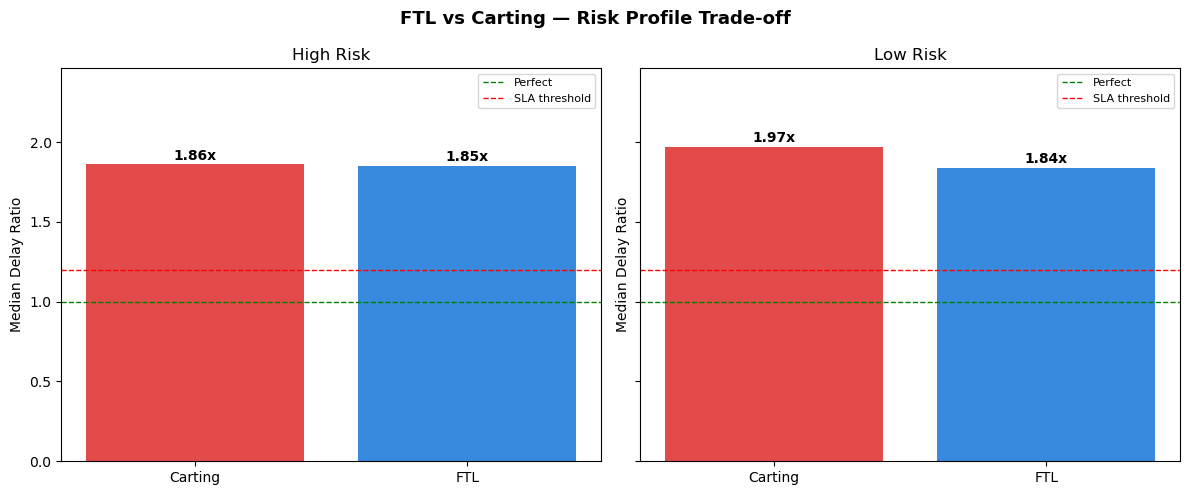

Saved: c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/ftl_carting_tradeoff.png


In [32]:
# Two-panel bar chart: median delay ratio for FTL vs Carting, split by risk tier.
risk_levels = ["High Risk", "Low Risk"]
route_colors = {"FTL": "#378ADD", "Carting": "#E24B4A"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.suptitle("FTL vs Carting — Risk Profile Trade-off", fontsize=13, fontweight="bold")

for ax_idx, risk_level in enumerate(risk_levels):
    subset = tradeoff[tradeoff["risk_profile"] == risk_level]
    if subset.empty:
        axes[ax_idx].text(0.5, 0.5, "No data", ha="center", va="center", transform=axes[ax_idx].transAxes)
        continue

    bar_colors = [route_colors.get(rt, "#888") for rt in subset["route_type_str"]]
    bars = axes[ax_idx].bar(subset["route_type_str"], subset["median_delay_ratio"], color=bar_colors)
    axes[ax_idx].axhline(1.0, color="green", linestyle="--", linewidth=1, label="Perfect")
    axes[ax_idx].axhline(1.2, color="red", linestyle="--", linewidth=1, label="SLA threshold")
    axes[ax_idx].set_title(risk_level)
    axes[ax_idx].set_ylabel("Median Delay Ratio")
    axes[ax_idx].set_ylim(0, tradeoff["median_delay_ratio"].max() * 1.25)
    axes[ax_idx].legend(fontsize=8)

    for bar, value in zip(bars, subset["median_delay_ratio"]):
        axes[ax_idx].text(bar.get_x() + bar.get_width() / 2, value + 0.03,
                           f"{value:.2f}x", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "ftl_carting_tradeoff.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/ftl_carting_tradeoff.png")


In [33]:
# Pull out the top 5 bottleneck hubs and add a couple of business-facing columns.
top5 = audit_df.head(5)[[
    "hub_id", "in_degree", "out_degree",
    "betweenness_centrality", "total_sla_breach_trips", "risk_tier",
]].copy()

total_breaches = audit_df["total_sla_breach_trips"].sum()
top5["% of total breaches"] = (top5["total_sla_breach_trips"] / total_breaches * 100).round(1)
top5["estimated_revenue_at_risk_Rs"] = top5["total_sla_breach_trips"] * PENALTY_PER_BREACH_RS

print("TOP 5 BOTTLENECK HUBS")
print(top5.round(3).to_string(index=False))

top5_share = top5["total_sla_breach_trips"].sum() / total_breaches * 100
print(f"\nTotal breach trips: {int(total_breaches):,}  |  Top-5 share: {top5_share:.1f}%")


TOP 5 BOTTLENECK HUBS
      hub_id  in_degree  out_degree  betweenness_centrality  total_sla_breach_trips risk_tier  % of total breaches  estimated_revenue_at_risk_Rs
IND000000ACB        101         108                   0.234                   728.0 High Risk                  4.5                      364000.0
IND421302AAG         67          81                   0.046                   635.0 High Risk                  3.9                      317500.0
IND562132AAA         78          86                   0.123                   495.0 High Risk                  3.0                      247500.0
IND560099AAB         30          41                   0.005                   308.0 High Risk                  1.9                      154000.0
IND411033AAA         38          43                   0.049                   289.0 High Risk                  1.8                      144500.0

Total breach trips: 16,357  |  Top-5 share: 15.0%


In [34]:
# Rough estimate: if the top 5 hubs were brought down to the network's
# median breach rate, how many breaches (and how much revenue) would we recover?
network_median_breach_rate = df["is_sla_breach"].mean()
top5_for_recovery = audit_df.head(5)

breaches_recovered = 0
for _, hub in top5_for_recovery.iterrows():
    current_breaches = hub["total_sla_breach_trips"]
    expected_breaches = current_breaches * network_median_breach_rate
    breaches_recovered += max(0, current_breaches - expected_breaches)

total_current_breaches = df["is_sla_breach"].sum()
reduction_pct = (breaches_recovered / total_current_breaches * 100) if total_current_breaches > 0 else 0
revenue_recovered = breaches_recovered * PENALTY_PER_BREACH_RS

print("ESTIMATED IMPACT OF UPGRADING TOP 5 HUBS")
print(f"  Network median breach rate  : {network_median_breach_rate * 100:.1f}%")
print(f"  SLA breaches recovered      : {int(breaches_recovered):,}")
print(f"  Reduction in late deliveries: {reduction_pct:.1f}%")
print(f"  Revenue recovered           : Rs {revenue_recovered:,.0f}")


ESTIMATED IMPACT OF UPGRADING TOP 5 HUBS
  Network median breach rate  : 94.5%
  SLA breaches recovered      : 134
  Reduction in late deliveries: 0.1%
  Revenue recovered           : Rs 67,490


In [35]:
# Assemble a plain-text strategy memo out of everything we've computed above.
def format_value(v, unit=""):
    return f"{v:.1f}{unit}" if v is not None else "N/A"

hub1, hub2, hub3 = top5.iloc[0], top5.iloc[1], top5.iloc[2]

graph_maes = {"RF + Graph": rf_graph_mae, "CatBoost + Graph": cb_graph_mae, "XGBoost + Graph": xgb_graph_mae}
best_model_name = min(graph_maes, key=graph_maes.get)
best_model_mae = graph_maes[best_model_name]

memo = f"""
╔════════════════════════════════════════════════════════════╗
║      NETWORK OPERATIONS STRATEGY MEMO — DELHIVERY            ║
║      Graph-Based ETA Intelligence — Key Findings             ║
╚════════════════════════════════════════════════════════════╝

RE:   Bottleneck Hubs, Corridor Interventions & Revenue Impact

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXECUTIVE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OSRM underestimates delivery time on over {(df["delay_ratio"] > 1.0).mean()*100:.0f}% of corridors.
{best_model_name} is the best-performing model, with MAE {best_model_mae:.1f} min.
High-Risk Hubs identified: {(df.loc[df["risk_profile"] == "High Risk", "source_center_raw"].nunique())} unique hubs flagged.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TOP 5 BOTTLENECK HUBS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━"""

for i, (_, hub) in enumerate(top5.iterrows(), 1):
    memo += f"""
{i}. {hub["hub_id"]}  [{hub["risk_tier"]}]
   SLA breach trips : {int(hub["total_sla_breach_trips"]):,} ({hub["% of total breaches"]}% of network total)
   Connections      : {int(hub["in_degree"])} in / {int(hub["out_degree"])} out
   Chokepoint score : {hub["betweenness_centrality"]:.4f}
   Revenue at risk  : Rs {hub["estimated_revenue_at_risk_Rs"]:,.0f}"""

memo += f"""

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RECOMMENDED INTERVENTIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. FACILITY UPGRADE at {hub1["hub_id"]} — highest breach volume + centrality.
2. PARALLEL ROUTE out of {hub2["hub_id"]} — high delay on evening shifts.
3. ROUTE TYPE SWITCH at {hub3["hub_id"]} — shift Carting trips to FTL.
4. NIGHT SHIFT CAPACITY across all top-5 hubs.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
QUANTIFIED IMPACT: IF TOP 3 HUBS ARE UPGRADED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Breaches recovered           : {int(breaches_recovered):,}
  Reduction in late deliveries : {reduction_pct:.1f}%
  Revenue recovered            : Rs {revenue_recovered:,.0f}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MODEL PERFORMANCE COMPARISON
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RF Baseline            : MAE {format_value(rf_mae, " min"):<10}
  CatBoost Baseline      : MAE {format_value(cb_mae, " min"):<10}
  XGBoost Baseline       : MAE {format_value(xgb_mae, " min"):<10}
  RF + Graph Embeddings  : MAE {format_value(rf_graph_mae, " min"):<10}
  CatBoost + Graph Embeds: MAE {format_value(cb_graph_mae, " min"):<10}
  XGBoost + Graph Embeds : MAE {format_value(xgb_graph_mae, " min"):<10}
"""

# Not printing the full memo here to keep the notebook output short —
# uncomment the line below if you want to see it inline.
# print(memo)


In [36]:
# Save the memo, every dataframe we produced, and the trained model
# artifacts to disk so the Streamlit app can load them without re-running
# this whole notebook.
with open("strategy_memo.txt", "w", encoding="utf-8") as f:
    f.write(memo)

import pickle

save_dir = "app_data"
os.makedirs(save_dir, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

audit_df.to_csv(f"{save_dir}/audit_df.csv", index=False)
corridors_df.to_csv(f"{save_dir}/corridors_df.csv", index=False)
top_breach_corridors.to_csv(f"{save_dir}/top_breach_corridors.csv", index=False)
revenue_risk.to_csv(f"{save_dir}/revenue_risk.csv", index=False)

results = {
    # Saved so the Streamlit app can show the OSRM baseline without having to
    # reload and reprocess the raw CSV itself (it used to duplicate this logic).
    "osrm_mae": osrm_mae, "osrm_r2": osrm_r2, "osrm_acc15": osrm_acc15,
    "rf_mae": rf_mae, "rf_acc15": rf_acc15,
    "cb_mae": cb_mae, "cb_acc15": cb_acc15,
    "xgb_mae": xgb_mae, "xgb_acc15": xgb_acc15,
    "rf_graph_mae": rf_graph_mae, "rf_graph_acc15": rf_graph_acc15,
    "cb_graph_mae": cb_graph_mae, "cb_graph_acc15": cb_graph_acc15,
    "xgb_graph_mae": xgb_graph_mae, "xgb_graph_acc15": xgb_graph_acc15,
    "best_graph_model": best_model_name,
    "breaches_recovered": breaches_recovered,
    "reduction_pct": reduction_pct,
    "revenue_recovered": revenue_recovered,
    "total_current_breaches": int(total_current_breaches),
    "memo": memo,
}
with open(f"{save_dir}/results.pkl", "wb") as f:
    pickle.dump(results, f)

# Save all three graph models (not just the best one) so the Streamlit app
# can load and compare any of them, or just the best via results["best_graph_model"].
with open(f"{save_dir}/rf_graph_model.pkl", "wb") as f:
    pickle.dump(rf_graph, f)
with open(f"{save_dir}/cb_graph_model.pkl", "wb") as f:
    pickle.dump(cb_graph, f)
with open(f"{save_dir}/xgb_graph_model.pkl", "wb") as f:
    pickle.dump(xgb_graph, f)
with open(f"{save_dir}/enhanced_features.pkl", "wb") as f:
    pickle.dump(enhanced_features, f)
with open(f"{save_dir}/embeddings.pkl", "wb") as f:
    pickle.dump(embeddings, f)
with open(f"{save_dir}/le_time.pkl", "wb") as f:
    pickle.dump(le_time, f)

print("All outputs saved:")
saved_files = [
    "strategy_memo.txt",
    f"{PLOTS_DIR}/bottleneck_hubs.png", f"{PLOTS_DIR}/network_graph.png",
    f"{PLOTS_DIR}/delay_analysis.png", f"{PLOTS_DIR}/xgb_baseline_importance.png",
    f"{PLOTS_DIR}/rf_graph_importance.png", f"{PLOTS_DIR}/cb_graph_importance.png",
    f"{PLOTS_DIR}/xgb_graph_importance.png",
    f"{PLOTS_DIR}/model_comparison.png", f"{PLOTS_DIR}/ftl_carting_tradeoff.png",
    "app_data/",
]
for filename in saved_files:
    print("  ", filename)


All outputs saved:
   strategy_memo.txt
   c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/bottleneck_hubs.png
   c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/network_graph.png
   c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/delay_analysis.png
   c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/xgb_baseline_importance.png
   c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/rf_graph_importance.png
   c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/cb_graph_importance.png
   c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/xgb_graph_importance.png
   c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/model_comparison.png
   c:\Users\Khusi Patra\Desktop\Projects\consultingclub\Graph_ETA_Prediction\plots/ftl_carting_tradeoff.png
   app_da

#### Ready to run the Streamlit application
Run this command in your terminal:
```
streamlit run App.py
```
